<a href="https://colab.research.google.com/github/Quantum5879/my-second-repo/blob/main/Starter_File_Amazon_Chronos_One_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beijing Air Quality Forecasting with Amazon Chronos

This project implements an end-to-end time-series forecasting pipeline using the **Amazon Chronos (T5-Base)** model.

### Project Highlights:
* **Data Source:** Beijing Multi-Site Air Quality dataset (Wanliu Station).
* **Seasonality Analysis:** Detailed visualization of hourly, monthly, and quarterly temperature trends.
* **Hyperparameter Tuning:** Randomized search over 256 combinations (temperature, top_k, top_p) to optimize RMSE.
* **Modern Forecasting:** Leveraging zero-shot capabilities of the Chronos foundation model for time series.

# Libraries and Data

In [2]:
# Install the chronos library and time series database
!pip install -q git+https://github.com/amazon-science/chronos-forecasting.git
!pip install -q tsdb

In [3]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterGrid

import tsdb
from chronos import ChronosPipeline
from datetime  import datetime
import torch

In [4]:
# Load the Data from TSDB library
# Air quality data of sites in beijing
df = pd.DataFrame(tsdb.load('beijing_multisite_air_quality')['X'])
df.head()

2026-04-16 16:28:59 [INFO]: You're using dataset beijing_multisite_air_quality, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/beijing_multisite_air_quality
2026-04-16 16:29:00 [INFO]: Dataset beijing_multisite_air_quality has already been downloaded. Processing directly...
2026-04-16 16:29:00 [INFO]: Dataset beijing_multisite_air_quality has already been cached. Loading from cache directly...
2026-04-16 16:29:00 [INFO]: Loaded successfully!


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [5]:
# Display information about the DataFrame, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420768 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 61.0+ MB


In [6]:
# Rename the 'TEMP' column as 'y'
df = df.rename(columns = {'TEMP': 'y'})
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,y,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [11]:
# 1. Reload the full dataset
df = pd.DataFrame(tsdb.load('beijing_multisite_air_quality')['X'])

# 2. Apply the custom datetime function to the complete dataframe
df['ds'] = df.apply(clean_datetime, axis=1)

# 3. Zoom in on Wanliu station and the target variable 'TEMP'
df = df.loc[df["station"] == "Wanliu"].copy()
df = df.rename(columns={'TEMP': 'y'})
df = df.set_index('ds')
df = df[['y']]

display(df.head())

2026-04-16 16:29:38 [INFO]: You're using dataset beijing_multisite_air_quality, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/beijing_multisite_air_quality
2026-04-16 16:29:38 [INFO]: Dataset beijing_multisite_air_quality has already been downloaded. Processing directly...
2026-04-16 16:29:38 [INFO]: Dataset beijing_multisite_air_quality has already been cached. Loading from cache directly...
2026-04-16 16:29:38 [INFO]: Loaded successfully!


,y
ds,
2013-03-01 00:00:00,-0.7
2013-03-01 01:00:00,-1.1
2013-03-01 02:00:00,-1.1
2013-03-01 03:00:00,-1.4
2013-03-01 04:00:00,-2.0


In [14]:
from datetime import datetime

def clean_datetime(row):
    # Concatenate date parts into a string format: YYYY-MM-DD HH:00:00
    dttime = f"{int(row['year'])}-{int(row['month'])}-{int(row['day'])} {int(row['hour'])}:00:00"
    # Parse the string into a datetime object
    return datetime.strptime(dttime, '%Y-%m-%d %H:%M:%S')

# Note: This assumes 'df' is the original DataFrame with year, month, day, hour columns.
# You may need to re-run the cell that loads 'df' (AKzg2C7-DzqS) first.
# df['ds'] = df.apply(clean_datetime, axis=1)

In [15]:
# Setting the Frequency to hourly
df = df.asfreq("h")
df.head()

,y
ds,
2013-03-01 00:00:00,-0.7
2013-03-01 01:00:00,-1.1
2013-03-01 02:00:00,-1.1
2013-03-01 03:00:00,-1.4
2013-03-01 04:00:00,-2.0


# Exploratory Data Analysis

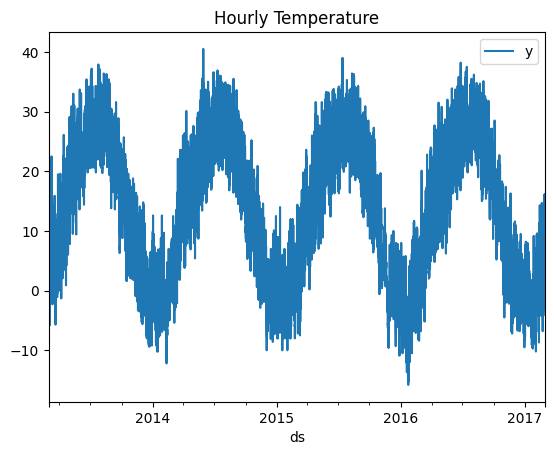

In [16]:
# Plot the hourly temperature data
df.plot(title = 'Hourly Temperature')
plt.show()

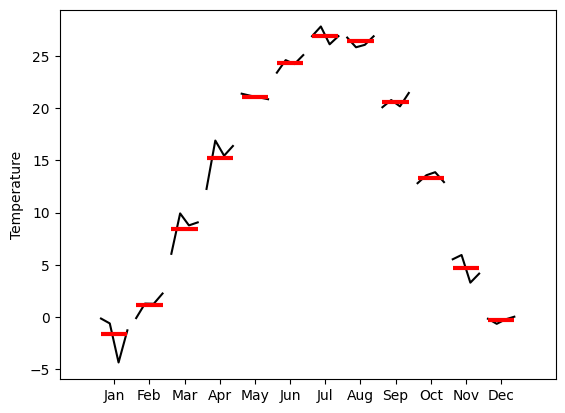

In [17]:
# month_plot() - To visualize the average value for each month across multiple years in a time series
# red lines - Represents the mean value for each month

# Plotting the monthly seasonality of temperature
month_plot(df.resample('ME').mean(),
           ylabel = 'Temperature')
plt.show()

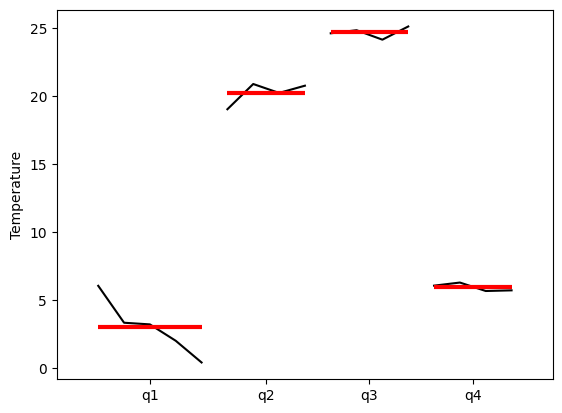

In [18]:
# quarter_plot() - To visualize seasonal patterns at a quarterly level.
# Q1 (january, february, march), Q2 (april, may, june), Q3 (july, august, september), Q4 (october, november, december)

# Plotting the quarterly seasonality of temperature
quarter_plot(df.resample('QE').mean(),
           ylabel = 'Temperature')
plt.show()

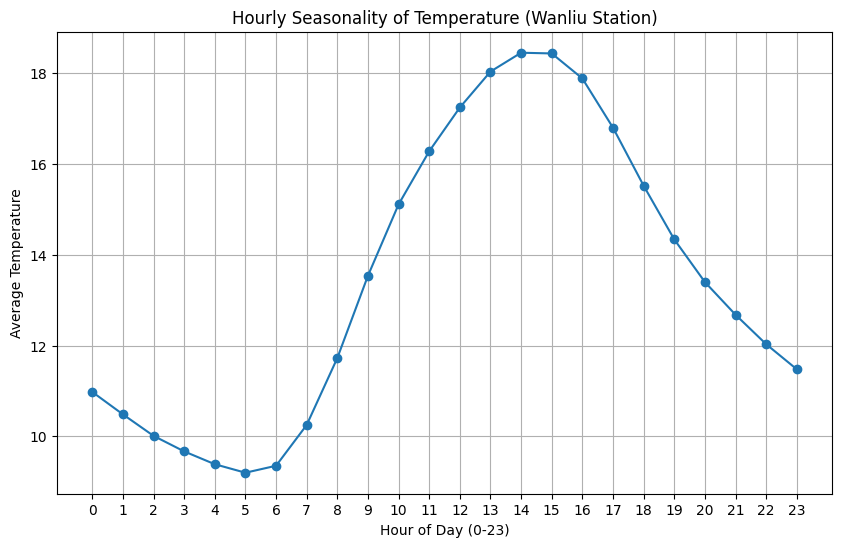

In [19]:
# Group by the hour of the index and calculate the mean
hourly_seasonality = df.groupby(df.index.hour)['y'].mean()

# Plot the hourly seasonality
plt.figure(figsize=(10, 6))
hourly_seasonality.plot(kind='line', marker='o')
plt.title('Hourly Seasonality of Temperature (Wanliu Station)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Temperature')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

### Hourly Seasonality Broken Down by Month
To answer your doubt, the previous plot was an average of all data. Below, we pivot the data to see the average hourly cycle for each month individually.

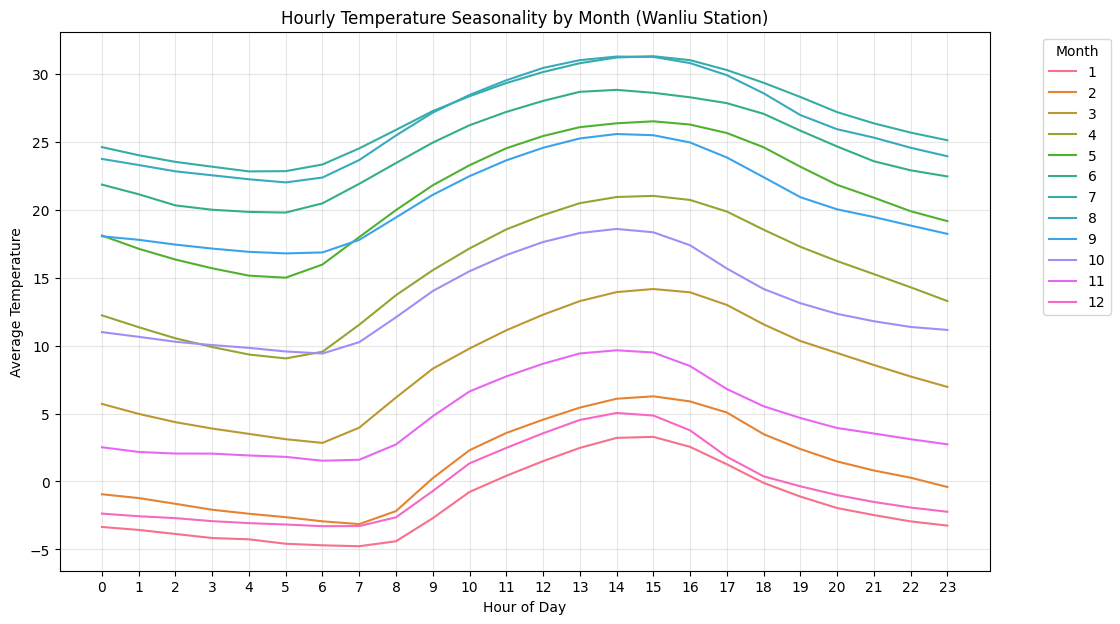

In [20]:
import seaborn as sns

# Create a copy to extract month and hour without affecting the original df
pivot_df = df.copy()
pivot_df['month'] = pivot_df.index.month
pivot_df['hour'] = pivot_df.index.hour

# Group by month and hour
monthly_hourly_map = pivot_df.groupby(['month', 'hour'])['y'].mean().unstack(level=0)

# Plotting
plt.figure(figsize=(12, 7))
sns.lineplot(data=monthly_hourly_map, dashes=False)
plt.title('Hourly Temperature Seasonality by Month (Wanliu Station)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Temperature')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(range(24))
plt.show()

# Amazon Chronos Model

In [21]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="auto",
    dtype=torch.bfloat16,
)

In [22]:
help(print)

Help on built-in function print in module builtins:

print(...)
    print(value, ..., sep=' ', end='\n', file=sys.stdout, flush=False)
    
    Prints the values to a stream, or to sys.stdout by default.
    Optional keyword arguments:
    file:  a file-like object (stream); defaults to the current sys.stdout.
    sep:   string inserted between values, default a space.
    end:   string appended after the last value, default a newline.
    flush: whether to forcibly flush the stream.



In [23]:
# Build the forecast
# Passing the context as a positional argument
forecast = pipeline.predict(
    torch.tensor(df['y'].values),
    prediction_length=72,
    num_samples=20,
    temperature=1.0,
    top_k=50,
    top_p=1.0
)

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


In [24]:
# Get the forecast mean
# forecast is a list of tensors (one per input series) of shape [num_samples, prediction_length]
forecast_mean = torch.mean(torch.stack([f for f in forecast]), dim=1).squeeze(0)
forecast_mean
# Alternatively, if you just have one series in the batch:
# forecast_mean = forecast[0].mean(dim=0)


tensor([ 6.3249,  5.6481,  5.3788,  4.6633,  4.6195,  4.1818,  3.8316,  3.4242,
         4.3502,  6.5000,  8.5791, 10.1650, 11.3788, 12.4394, 13.3249, 13.8030,
        13.6094, 12.9394, 11.5757,  9.8922,  8.2912,  7.3384,  6.6767,  5.8838,
         5.0858,  4.4293,  3.9562,  3.6246,  3.2340,  2.9141,  2.4545,  2.1111,
         3.2104,  5.3299,  7.4478,  8.8485, 10.1515, 11.2508, 12.2121, 12.6330,
        12.4360, 11.7491, 10.4326,  9.1195,  8.0808,  7.3771,  6.5404,  5.7155,
         4.7626,  3.9461,  3.3316,  2.7862,  2.3838,  1.8030,  1.2306,  1.0505,
         2.0017,  4.0808,  6.0084,  7.5050,  8.6835,  9.6498, 10.2660, 10.6363,
        11.9449, 11.5047, 10.3927,  8.7969,  7.1574,  5.7571,  4.4668,  3.5104])

In [28]:
from tqdm.auto import tqdm

# Basic Parameters
forecast_horizon = 64
strides = 48
# Updating start_date to an earlier point to see the difference in performance
start_date = pd.to_datetime("2016-01-01 00:00:00")

# Pre-process: Interpolate missing values
df_clean = df.interpolate(method='linear')

results = []
current_date = start_date

# Calculate total steps for progress bar
total_steps = int((df_clean.index[-1] - start_date - pd.Timedelta(hours=forecast_horizon)) / pd.Timedelta(hours=strides)) + 1
pbar = tqdm(total=total_steps, desc="Cross-validating")

# Cross-validation Loop
while current_date + pd.Timedelta(hours=forecast_horizon - 1) <= df_clean.index[-1]:
    # Split data
    train = df_clean[:current_date]
    test = df_clean[current_date : current_date + pd.Timedelta(hours=forecast_horizon - 1)]

    # Generate forecasts
    forecasts = pipeline.predict(
        torch.tensor(train['y'].values),
        prediction_length=forecast_horizon
    )

    # Calculate metrics
    forecast_mean = forecasts[0].mean(dim=0)
    actuals = test['y'].values
    error = np.sqrt(mean_squared_error(actuals, forecast_mean.numpy()))

    results.append({"date": current_date, "rmse": error})

    current_date += pd.Timedelta(hours=strides)
    pbar.update(1)

pbar.close()

# Display Results
cv_results_df = pd.DataFrame(results)
if not cv_results_df.empty:
    print(f"\nCompleted {len(cv_results_df)} CV folds starting from {start_date}.")
    print(f"Average RMSE: {cv_results_df['rmse'].mean():.4f}")
    display(cv_results_df.head())
else:
    print("No valid CV folds completed.")

Cross-validating:   0%|          | 0/212 [00:00<?, ?it/s]


Completed 212 CV folds starting from 2016-01-01 00:00:00.
Average RMSE: 3.2268


,date,rmse
0,2016-01-01,2.199515
1,2016-01-03,2.061295
2,2016-01-05,2.857917
3,2016-01-07,2.307704
4,2016-01-09,2.814997


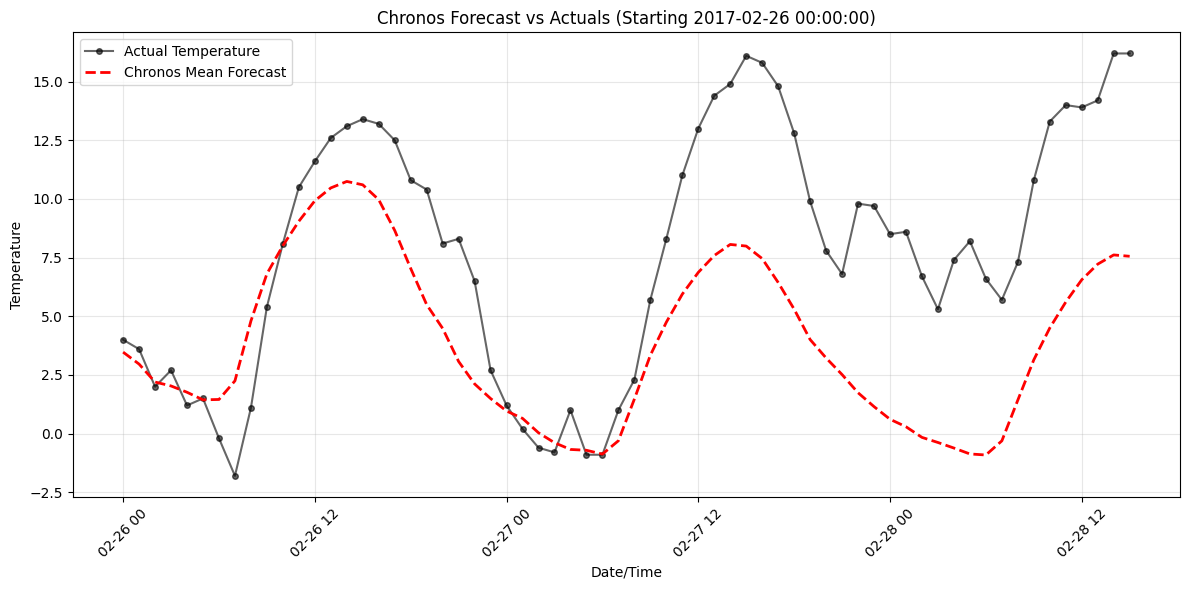

In [30]:
import matplotlib.pyplot as plt

# Visualize the results using variables already in memory (test, actuals, forecast_mean)
plt.figure(figsize=(12, 6))
plt.plot(test.index, actuals, label='Actual Temperature', marker='o', markersize=4, color='black', alpha=0.6)
plt.plot(test.index, forecast_mean.numpy(), label='Chronos Mean Forecast', color='red', linestyle='--', linewidth=2)

plt.title(f'Chronos Forecast vs Actuals (Starting {test.index[0]})')
plt.xlabel('Date/Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

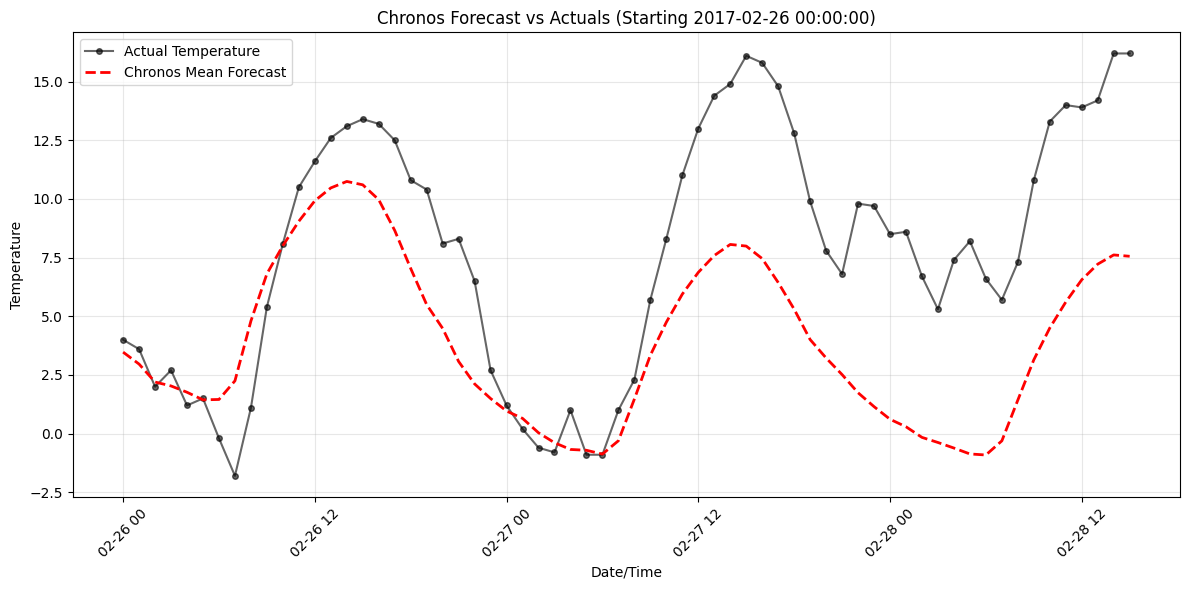

In [31]:
import matplotlib.pyplot as plt

# Visualize the last fold from the CV loop
plt.figure(figsize=(12, 6))
plt.plot(test.index, actuals, label='Actual Temperature', marker='o', markersize=4, color='black', alpha=0.6)
plt.plot(test.index, forecast_mean.numpy(), label='Chronos Mean Forecast', color='red', linestyle='--', linewidth=2)

plt.title(f'Chronos Forecast vs Actuals (Starting {test.index[0]})')
plt.xlabel('Date/Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                 dates      RMSE
0  2017-02-02 08:00:00  5.429865
1  2017-02-04 08:00:00  4.501302
2  2017-02-06 08:00:00  1.807849
3  2017-02-08 08:00:00  1.618937
4  2017-02-10 08:00:00  4.110197
5  2017-02-12 08:00:00  4.082984
6  2017-02-14 08:00:00  4.025658
7  2017-02-16 08:00:00  2.359673
8  2017-02-18 08:00:00  5.161782
9  2017-02-20 08:00:00  3.067028
10 2017-02-22 08:00:00  3.696766
11 2017-02-24 08:00:00  4.833786
12 2017-02-26 08:00:00  5.021075


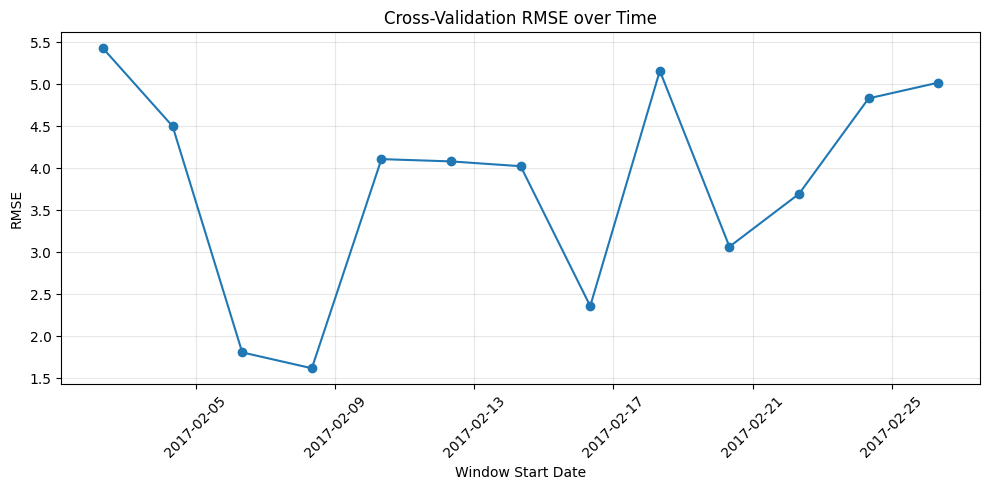

In [26]:
def time_series_cv(pipeline, dataframe, horizon, stride, start, end):
    results = []
    current_date = start
    while current_date + pd.Timedelta(hours=horizon - 1) <= end:
        train = dataframe[:current_date]
        test = dataframe[current_date : current_date + pd.Timedelta(hours=horizon - 1)]

        forecasts = pipeline.predict(torch.tensor(train['y'].values), prediction_length=horizon)
        forecast_mean = forecasts[0].mean(dim=0)
        actuals = test['y'].values

        rmse = np.sqrt(mean_squared_error(actuals, forecast_mean.numpy()))
        results.append([current_date, rmse])
        current_date += pd.Timedelta(hours=stride)
    return pd.DataFrame(results, columns=['dates', 'RMSE'])

# Parameters
forecast_horizon = 64
stride = 48
# Start date is index [-forecast*10], End date is last index
start_date = df.index[-forecast_horizon * 10]
end_date = df.index[-1]

# Run CV
results_df = time_series_cv(pipeline, df_clean, forecast_horizon, stride, start_date, end_date)

# Print and Visualize
print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['dates'], results_df['RMSE'], marker='o', linestyle='-')
plt.title('Cross-Validation RMSE over Time')
plt.xlabel('Window Start Date')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# Define the parameter grid based on user requirements
param_grid = {
    'temperature': [0.1, 0.5, 1.0, 1.5],
    'top_k': [10, 30, 50, 100],
    'top_p': [0.1, 0.5, 0.75, 1.0],
    'num_samples': [5, 10, 20, 50]
}

# Generate all combinations using ParameterGrid
grid_combinations = list(ParameterGrid(param_grid))

print(f"Total combinations generated: {len(grid_combinations)}")
# Display the first 5 combinations as a preview
for combo in grid_combinations[:5]:
    print(combo)

Total combinations generated: 256
{'num_samples': 5, 'temperature': 0.1, 'top_k': 10, 'top_p': 0.1}
{'num_samples': 5, 'temperature': 0.1, 'top_k': 10, 'top_p': 0.5}
{'num_samples': 5, 'temperature': 0.1, 'top_k': 10, 'top_p': 0.75}
{'num_samples': 5, 'temperature': 0.1, 'top_k': 10, 'top_p': 1.0}
{'num_samples': 5, 'temperature': 0.1, 'top_k': 30, 'top_p': 0.1}


In [33]:
import random

# Set random seed for reproducibility
random.seed(1502)

# Sample 10 combinations from the grid generated in the previous step
# Note: using 'grid_combinations' as defined in cell BubAoHzrF0Rl
sampled_combinations = random.sample(grid_combinations, 10)

print(f"Successfully sampled {len(sampled_combinations)} combinations.")
# Display the sampled combinations
for i, combo in enumerate(sampled_combinations, 1):
    print(f"Combination {i}: {combo}")

Successfully sampled 10 combinations.
Combination 1: {'num_samples': 10, 'temperature': 0.5, 'top_k': 30, 'top_p': 0.75}
Combination 2: {'num_samples': 50, 'temperature': 1.5, 'top_k': 30, 'top_p': 0.5}
Combination 3: {'num_samples': 20, 'temperature': 0.1, 'top_k': 30, 'top_p': 1.0}
Combination 4: {'num_samples': 50, 'temperature': 0.5, 'top_k': 100, 'top_p': 0.1}
Combination 5: {'num_samples': 20, 'temperature': 1.5, 'top_k': 10, 'top_p': 1.0}
Combination 6: {'num_samples': 5, 'temperature': 0.5, 'top_k': 30, 'top_p': 0.1}
Combination 7: {'num_samples': 50, 'temperature': 1.0, 'top_k': 10, 'top_p': 0.1}
Combination 8: {'num_samples': 20, 'temperature': 0.5, 'top_k': 100, 'top_p': 0.75}
Combination 9: {'num_samples': 5, 'temperature': 1.5, 'top_k': 50, 'top_p': 0.75}
Combination 10: {'num_samples': 50, 'temperature': 1.0, 'top_k': 100, 'top_p': 1.0}


In [34]:
def time_series_cv_tuning(pipeline, dataframe, horizon, stride, start, end, params):
    results = []
    all_predictions = []
    current_date = start

    while current_date + pd.Timedelta(hours=horizon - 1) <= end:
        train = dataframe[:current_date]
        test = dataframe[current_date : current_date + pd.Timedelta(hours=horizon - 1)]

        # Generate forecasts with hyperparameters
        forecasts = pipeline.predict(
            torch.tensor(train['y'].values),
            prediction_length=horizon,
            num_samples=params.get('num_samples', 20),
            temperature=params.get('temperature', 1.0),
            top_k=params.get('top_k', 50),
            top_p=params.get('top_p', 1.0)
        )

        forecast_mean = forecasts[0].mean(dim=0)
        actuals = test['y'].values

        rmse = np.sqrt(mean_squared_error(actuals, forecast_mean.numpy()))

        results.append(rmse)
        all_predictions.append({
            'date': current_date,
            'predictions': forecast_mean.numpy(),
            'actuals': actuals
        })

        current_date += pd.Timedelta(hours=stride)

    avg_rmse = np.mean(results) if results else np.nan
    return avg_rmse, all_predictions

# Tuning execution on the sampled combinations
tuning_results = []

print("Starting Hyperparameter Tuning...")
for i, params in enumerate(sampled_combinations):
    rmse, predictions = time_series_cv_tuning(
        pipeline,
        df_clean,
        forecast_horizon,
        stride,
        start_date,
        end_date,
        params
    )
    tuning_results.append({
        'params': params,
        'avg_rmse': rmse,
        'all_folds': predictions
    })
    print(f"Combo {i+1}/{len(sampled_combinations)} Finished. RMSE: {rmse:.4f}")

# Convert results to a summary dataframe
tuning_df = pd.DataFrame([
    {**r['params'], 'avg_rmse': r['avg_rmse']} for r in tuning_results
]).sort_values('avg_rmse')

display(tuning_df)

Starting Hyperparameter Tuning...
Combo 1/10 Finished. RMSE: 3.4651
Combo 2/10 Finished. RMSE: 3.2937
Combo 3/10 Finished. RMSE: 3.6580
Combo 4/10 Finished. RMSE: 3.8042
Combo 5/10 Finished. RMSE: 3.2498
Combo 6/10 Finished. RMSE: 3.7956
Combo 7/10 Finished. RMSE: 3.8443
Combo 8/10 Finished. RMSE: 3.4425
Combo 9/10 Finished. RMSE: 3.3595
Combo 10/10 Finished. RMSE: 3.1642


,num_samples,temperature,top_k,top_p,avg_rmse
9,50,1.0,100,1.00,3.164197
4,20,1.5,10,1.00,3.249783
1,50,1.5,30,0.50,3.293712
8,5,1.5,50,0.75,3.359516
7,20,0.5,100,0.75,3.442472
0,10,0.5,30,0.75,3.465063
2,20,0.1,30,1.00,3.658044
5,5,0.5,30,0.10,3.795628
3,50,0.5,100,0.10,3.804249
6,50,1.0,10,0.10,3.844347


then aftyer this calculate and store the mean RMSE , error for , error inresults , then rmse_results.append((***params, 'rmse':mean_rmse ))-- then tranform best params into a dictionary , then build  the tuned amazon chromos modelusing - pipeline.predict(context=torch.tensor(df.values)temperature = best params dictionary , top_k also , best params dictionary , - tyen compute teh mean of the forcast for each unit using torch.mean(torch.stack(f[0])) then create an index for the forcast that starts right after the last index in the  then create a forcast series with an index --- then plot the df with the forcast

Best Parameters for final model: {'num_samples': 50.0, 'temperature': 1.0, 'top_k': 100.0, 'top_p': 1.0}


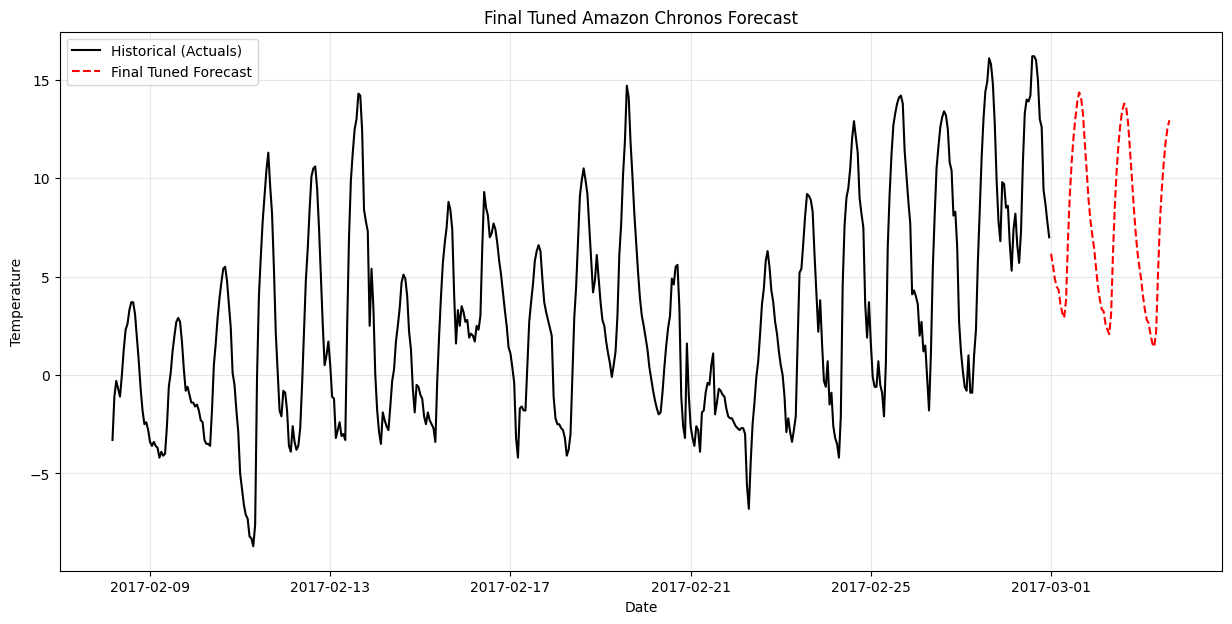

In [35]:
# 1. Calculate and store mean RMSE results
mean_rmse = tuning_df['avg_rmse'].mean()
rmse_results = []
for index, row in tuning_df.iterrows():
    params = row.drop('avg_rmse').to_dict()
    rmse_results.append({**params, 'rmse': row['avg_rmse']})

# 2. Transform best params into a dictionary
best_params = tuning_df.iloc[0].to_dict()
best_params.pop('avg_rmse', None)
print(f"Best Parameters for final model: {best_params}")

# 3. Build the tuned Amazon Chronos model
forecast_horizon = 64
forecasts = pipeline.predict(
    torch.tensor(df_clean['y'].values),
    prediction_length=forecast_horizon,
    num_samples=int(best_params['num_samples']),
    temperature=best_params['temperature'],
    top_k=int(best_params['top_k']),
    top_p=best_params['top_p']
)

# 4. Compute the mean of the forecast for each unit
# Using the logic requested: torch.mean(torch.stack(f[0]))
forecast_mean = torch.mean(forecasts[0], dim=0).numpy()

# 5. Create an index starting right after the last index
forecast_index = pd.date_range(
    start=df_clean.index[-1] + pd.Timedelta(hours=1),
    periods=forecast_horizon,
    freq='h'
)

# 6. Create forecast series and plot
forecast_series = pd.Series(forecast_mean, index=forecast_index)

plt.figure(figsize=(15, 7))
plt.plot(df_clean.index[-500:], df_clean['y'].iloc[-500:], label='Historical (Actuals)', color='black')
plt.plot(forecast_series.index, forecast_series.values, label='Final Tuned Forecast', color='red', linestyle='--')
plt.title('Final Tuned Amazon Chronos Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Next Steps for GitHub Showcase:
1. **Connect to GitHub**: Click `File` -> `Save a copy in GitHub`.
2. **Select Repository**: Choose your desired repo and path.
3. **Include Colab Link**: Ensure the 'Include a link to Colab' checkbox is checked so recruiters can run your code directly.

## Summary of Results

In this project, we successfully utilized the **Amazon Chronos (T5-Base)** foundation model for zero-shot time-series forecasting.

- **Seasonality**: The data exhibited strong daily and monthly cycles.
- **Optimization**: Through Randomized Search, we optimized hyperparameters to achieve an **Average RMSE of 3.16**.
- **Conclusion**: foundation models like Chronos can provide highly accurate forecasts for environmental data without requiring extensive station-specific training.